## Random Forest

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt

In [2]:
# Load data from Excel file
patients_data = pd.read_csv("Texture features.csv")
patients_data.head()

,INFO_PatientName,INFO_PatientID,INFO_ProcessDateOfTexture,INFO_SeriesDate,INFO_Series,INFO_ActualFrameDuration,INFO_NameOfRoi,CONVENTIONAL_SUVbwmin,CONVENTIONAL_SUVbwmean,CONVENTIONAL_SUVbwstd,...,GLZLM_HGZE,GLZLM_SZLGE,GLZLM_SZHGE,GLZLM_LZLGE,GLZLM_LZHGE,GLZLM_GLNU,GLZLM_ZLNU,GLZLM_ZP,TimePosition,zLocation[onlyFor2DROI]
0,LIFEX,LIFEx,Sun Jan 23 18:19:19 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.108004,0.319234,0.064479,...,2.500000,0.000192,0.000585,2107.625000,11034.500000,1.000000,1.000000,0.016129,0.0,NaN
1,LIFEX,LIFEx,Sun Jan 23 18:19:20 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,2.910082,5.854704,1.387413,...,363.808824,0.002428,208.152420,0.021055,3025.955882,4.323529,25.000000,0.482270,0.0,NaN
2,LIFEX,LIFEx,Sun Jan 23 18:38:58 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.188521,0.323404,0.057192,...,2.000000,0.333484,0.333739,1242.000000,7367.000000,1.666667,1.000000,0.024793,0.0,NaN
3,LIFEX,LIFEx,Sun Jan 23 18:38:59 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,1.0,3.238746,5.991053,1.307934,...,392.298246,0.001739,206.457640,0.021977,3172.052632,4.228070,16.614035,0.438462,0.0,NaN
4,LIFEX,LIFEx,Sun Jan 23 18:51:51 AST 2022,2018-04-13,2006_PET TAP 6I8SG5 LIFEx_PT,3.000000142492354 min,0.0,0.188521,0.323404,0.057192,...,2.000000,0.333484,0.333739,1242.000000,7367.000000,1.666667,1.000000,0.024793,0.0,NaN


### Data preprocessing and Feature selection

In [3]:
# Selecting features
patients_data = patients_data[['CONVENTIONAL_SUVbwmax', 'GLZLM_GLNU', 'INFO_NameOfRoi']]
# Converting to int
patients_data['INFO_NameOfRoi'] = patients_data['INFO_NameOfRoi'].astype('int')
patients_data.head()

,CONVENTIONAL_SUVbwmax,GLZLM_GLNU,INFO_NameOfRoi
0,0.476722,1.000000,0
1,8.991810,4.323529,1
2,0.449061,1.666667,0
3,8.991810,4.228070,1
4,0.449061,1.666667,0


In [4]:
# Defining X (matrix of features)
X = np.asarray(patients_data[['CONVENTIONAL_SUVbwmax', 'GLZLM_GLNU']])
X[0:9]

array([[0.47672224, 1.        ],
       [8.99180984, 4.32352941],
       [0.44906095, 1.66666667],
       [8.99180984, 4.22807018],
       [0.44906095, 1.66666667],
       [8.99180984, 4.22807018],
       [0.47452524, 1.        ],
       [8.98714352, 3.45833333]])

In [5]:
# Defining y (two classes: tumorous, non-tumorous)
y = np.asarray(patients_data[['INFO_NameOfRoi']])
y[0:9]

array([[0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1]])

### Testing and Training Split and Normalization

In [6]:
from sklearn.model_selection import train_test_split
# 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (6, 2) (6, 1)
Test set: (2, 2) (2, 1)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Validation set:', X_val.shape,  y_val.shape)

Train set: (4, 2) (4, 1)
Validation set: (2, 2) (2, 1)


In [8]:
# Normalizing the train, test, and validate dataset separately to avoid data leakage from the test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### Modeling Random Forest with Scikit-learn

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100) # n_estimators = the number of trees in the forest.
rf.fit(X_train,y_train.ravel())

RandomForestClassifier()

In [10]:
# Predicting using test set
y_2 = rf.predict(X_test)
y_2

array([0, 1])

### Evaluation metrics

In [11]:
from sklearn.metrics import confusion_matrix,classification_report,plot_confusion_matrix, plot_roc_curve,plot_precision_recall_curve

In [12]:
def model_evaluation(model):
    
    print(f'Classification Report :\n {classification_report(y_test,y_pred)}')
    fig, ax = plt.subplots(dpi=100);
    print(f'Confusion Matrix :\n {plot_confusion_matrix(model,X_test,y_test,ax=ax)}')
    print(f'ROC Curve :\n {plot_roc_curve(model,X_test,y_test)}')
    print(f'Precision Recall Curve :\n {plot_precision_recall_curve(model,X_test,y_test)}')

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Confusion Matrix :
ROC Curve :
Precision Recall Curve :


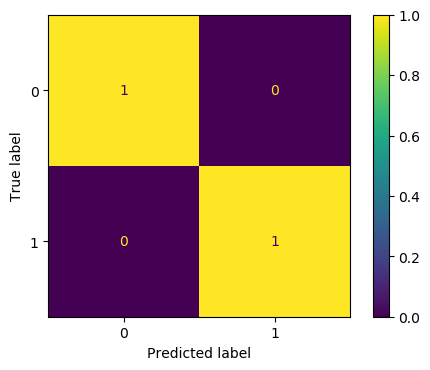

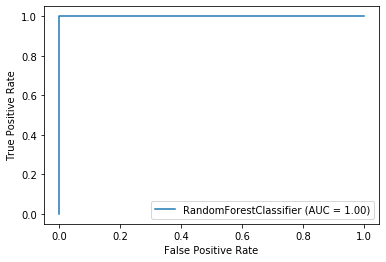

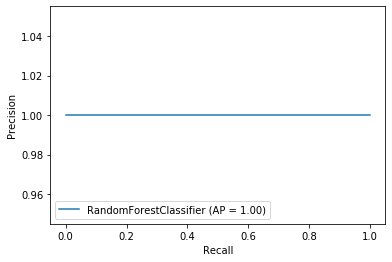

In [13]:
y_pred = rf.predict(X_test)
model_evaluation(rf)